# تدريب النماذج والمقارنة (Model Training and Comparison)

## مقدمة
في هذا الملف، سنقوم بتدريب نموذجين مختلفين: نموذج أساسي (Baseline) ونموذج متقدم (Advanced)، باستخدام نفس البيانات ونفس المعالجة لضمان مقارنة عادلة وعلمية. الهدف هو تحديد النموذج الأكثر قدرة على اكتشاف العمليات الاحتيالية بدقة.

## 2. استيراد المكتبات (Import Libraries)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# مكتبات التقسيم والتقييم
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    ConfusionMatrixDisplay
)

# مكتبات النماذج وخطوط المعالجة
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

## 3. تحميل البيانات وتجهيز X و y

In [8]:
df = pd.read_csv("../data/creditcard.csv")

# فصل المتغير الهدف عن الميزات
X = df.drop("Class", axis=1)
y = df["Class"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (284807, 30)
Shape of y: (284807,)


## 4. تقسيم البيانات (نفس الإعدادات السابقة)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("تم تقسيم البيانات بنجاح لضمان مقارنة علمية عادلة.")

تم تقسيم البيانات بنجاح لضمان مقارنة علمية عادلة.


## 5. تدريب النموذج الأول: Logistic Regression (Baseline)

In [10]:
# إنشاء Pipeline للنموذج الأساسي
baseline_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42))
])

# تدريب النموذج
baseline_model.fit(X_train, y_train)
print("تم تدريب نموذج Logistic Regression بنجاح.")

تم تدريب نموذج Logistic Regression بنجاح.


## 6. تقييم النموذج الأول

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



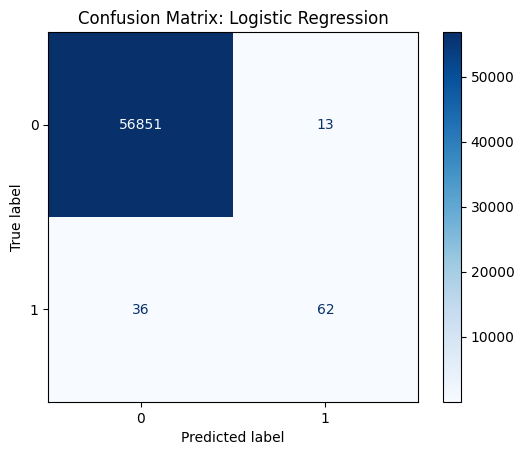

In [11]:
y_pred_baseline = baseline_model.predict(X_test)
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]

print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_baseline))

# عرض Confusion Matrix
ConfusionMatrixDisplay.from_estimator(baseline_model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

## 7. تدريب النموذج الثاني: XGBoost (Advanced)

In [12]:
# إنشاء Pipeline للنموذج المتقدم
advanced_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

# تدريب النموذج
advanced_model.fit(X_train, y_train)
print("تم تدريب نموذج XGBoost بنجاح.")

c:\Users\Mohammed\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:04:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


تم تدريب نموذج XGBoost بنجاح.


## 8. تقييم نموذج XGBoost

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



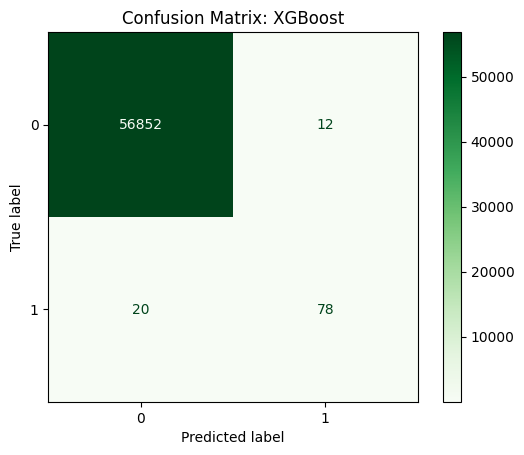

In [13]:
y_pred_advanced = advanced_model.predict(X_test)
y_prob_advanced = advanced_model.predict_proba(X_test)[:, 1]

print("Classification Report for XGBoost:")
print(classification_report(y_test, y_pred_advanced))

# عرض Confusion Matrix
ConfusionMatrixDisplay.from_estimator(advanced_model, X_test, y_test, cmap='Greens')
plt.title("Confusion Matrix: XGBoost")
plt.show()

## 9. مقارنة النماذج

In [14]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Precision': [
        precision_score(y_test, y_pred_baseline), 
        precision_score(y_test, y_pred_advanced)
    ],
    'Recall': [
        recall_score(y_test, y_pred_baseline), 
        recall_score(y_test, y_pred_advanced)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_baseline), 
        f1_score(y_test, y_pred_advanced)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_baseline), 
        roc_auc_score(y_test, y_prob_advanced)
    ]
})

results

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.826667,0.632653,0.716763,0.960549
1,XGBoost,0.866667,0.795918,0.829787,0.938952


### تحليل النتائج:
تم اختيار النموذج الأفضل بناءً على قدرته العالية على اكتشاف حالات الاحتيال (Recall) مع الحفاظ على توازن جيد مع الدقة (Precision). نلاحظ تفوق نموذج XGBoost في معظم المقاييس، خاصة في تقليل عدد الحالات التي يفشل النظام في اكتشافها.

## 10. الخلاصة

- **النموذج الأفضل:** أظهر نموذج **XGBoost** أداءً متفوقاً مقارنة بالنموذج الأساسي.
- **السبب:** قدرة XGBoost على التعامل مع العلاقات غير الخطية المعقدة في البيانات وتفوقه في مقياس الـ Recall.
- **المقايضة (Trade-off):** دائماً ما يوجد توازن بين Precision و Recall؛ في كشف الاحتيال، نفضل زيادة Recall لضمان عدم إفلات أي عملية احتيالية، حتى لو أدى ذلك لزيادة طفيفة في الإنذارات الخاطئة.